# Phase 2: Multi-Model Benchmarking, Bayesian Optimization & Probability Calibration

## Executive Summary & Objectives
In financial risk and customer retention modeling, **raw accuracy is insufficient**. We must optimize for:
1. **Discrimination on Imbalanced Targets**: Measured via **PR-AUC (Average Precision)** and **ROC-AUC** using 5-Fold Stratified Cross-Validation.
2. **Algorithmic Diversity**: Benchmarking across a **Model Zoo** (Logistic Regression, Random Forest, LightGBM, XGBoost, and CatBoost).
3. **Bayesian Hyperparameter Optimization**: Automated tuning using **Optuna**.
4. **Probability Calibration**: Platt Scaling (Sigmoid) evaluated with **Brier Score Loss** and **Expected Calibration Error (ECE)** to ensure predicted probabilities match true banking default/churn rates.
5. **Statistical Rigor**: 95% Bootstrap Confidence Intervals across all key performance metrics.

In [1]:
import sys
from pathlib import Path

# Ensure project root is in sys.path
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import ARTIFACTS_DIR, FIGURES_DIR, RAW_DATA_PATH, PROCESSED_DATA_PATH
from src.evaluate import generate_evaluation_report, compute_bootstrap_ci

print("Phase 2 benchmarking environment ready.")

Phase 2 benchmarking environment ready.


## 1. Cross-Validation Benchmarks & Leaderboard Analysis

In [2]:
# Load serialized metrics and fitted models
with open(ARTIFACTS_DIR / "metrics_summary.json", "r") as f:
    metrics_summary = json.load(f)

cv_benchmarks = pd.DataFrame(metrics_summary["cv_benchmarks"]).T
cv_benchmarks.sort_values(by=["CV_PR_AUC", "CV_ROC_AUC"], ascending=False)

,CV_ROC_AUC,CV_PR_AUC,CV_Brier_Score
CatBoost,0.999212,0.997775,0.001372
Logistic_Regression,0.999003,0.997418,0.001387
XGBoost,0.999132,0.997336,0.001368
LightGBM,0.999113,0.996233,0.001408
Random_Forest,0.998942,0.995675,0.001449


## 2. Holdout Test Set Performance & Champion Metrics

In [3]:
test_metrics = metrics_summary["test_metrics"]
print(f"Champion Architecture: {metrics_summary['champion_model']}")
print(f"Test ROC-AUC:          {test_metrics['roc_auc']:.4f}")
print(f"Test PR-AUC:           {test_metrics['pr_auc']:.4f}")
print(f"Uncalibrated Brier:    {test_metrics['brier_score_uncalibrated']:.4f}")
print(f"Calibrated Brier:      {test_metrics['brier_score_calibrated']:.4f}")
print(f"Optimal Threshold p*:  {test_metrics['optimal_threshold']:.3f}")
print(f"Max Net Profit Saved:  €{test_metrics['max_net_profit_saved']:,.2f}")

Champion Architecture: CatBoost
Test ROC-AUC:          0.9982
Test PR-AUC:           0.9973
Uncalibrated Brier:    0.0015
Calibrated Brier:      0.0015
Optimal Threshold p*:  0.100
Max Net Profit Saved:  €617,880.10


## 3. Probability Calibration & Reliability Diagnostics

Why calibration matters in banking: A raw model might output `0.85` confidence, but if only 60% of such customers actually churn, our financial retention budget will be misallocated.
Calibrated probabilities ensure that if we predict a 30% churn risk, approximately 30 out of 100 customers truly exit.

In [4]:
results_df = generate_evaluation_report()
results_df


--- Running Comparative Model Evaluation & Calibration Analysis ---

--- Comparative Metrics Leaderboard ---
                         Model  ROC-AUC  PR-AUC  Brier Score  F1 (th=0.5)  Recall (th=0.5)  Precision (th=0.5)
           Logistic_Regression   0.9994  0.9984       0.0015       0.9963           0.9951              0.9975
                 Random_Forest   0.9973  0.9965       0.0016       0.9963           0.9951              0.9975
                      LightGBM   0.9973  0.9967       0.0015       0.9963           0.9951              0.9975
                       XGBoost   0.9965  0.9964       0.0015       0.9963           0.9951              0.9975
                      CatBoost   0.9983  0.9973       0.0015       0.9963           0.9951              0.9975
CatBoost (Calibrated, th=0.10)   0.9982  0.9973       0.0015       0.9963           0.9951              0.9975

--- Champion 95% Bootstrap Confidence Intervals ---
 ROC_AUC     : 0.9981 (95% CI: [0.9946, 1.0000])
 PR_AUC    

,Model,ROC-AUC,PR-AUC,Brier Score,F1 (th=0.5),Recall (th=0.5),Precision (th=0.5)
0,Logistic_Regression,0.9994,0.9984,0.0015,0.9963,0.9951,0.9975
1,Random_Forest,0.9973,0.9965,0.0016,0.9963,0.9951,0.9975
2,LightGBM,0.9973,0.9967,0.0015,0.9963,0.9951,0.9975
3,XGBoost,0.9965,0.9964,0.0015,0.9963,0.9951,0.9975
4,CatBoost,0.9983,0.9973,0.0015,0.9963,0.9951,0.9975
5,"CatBoost (Calibrated, th=0.10)",0.9982,0.9973,0.0015,0.9963,0.9951,0.9975


## 4. Visual Diagnostics (ROC, PR, and Calibration Curves)

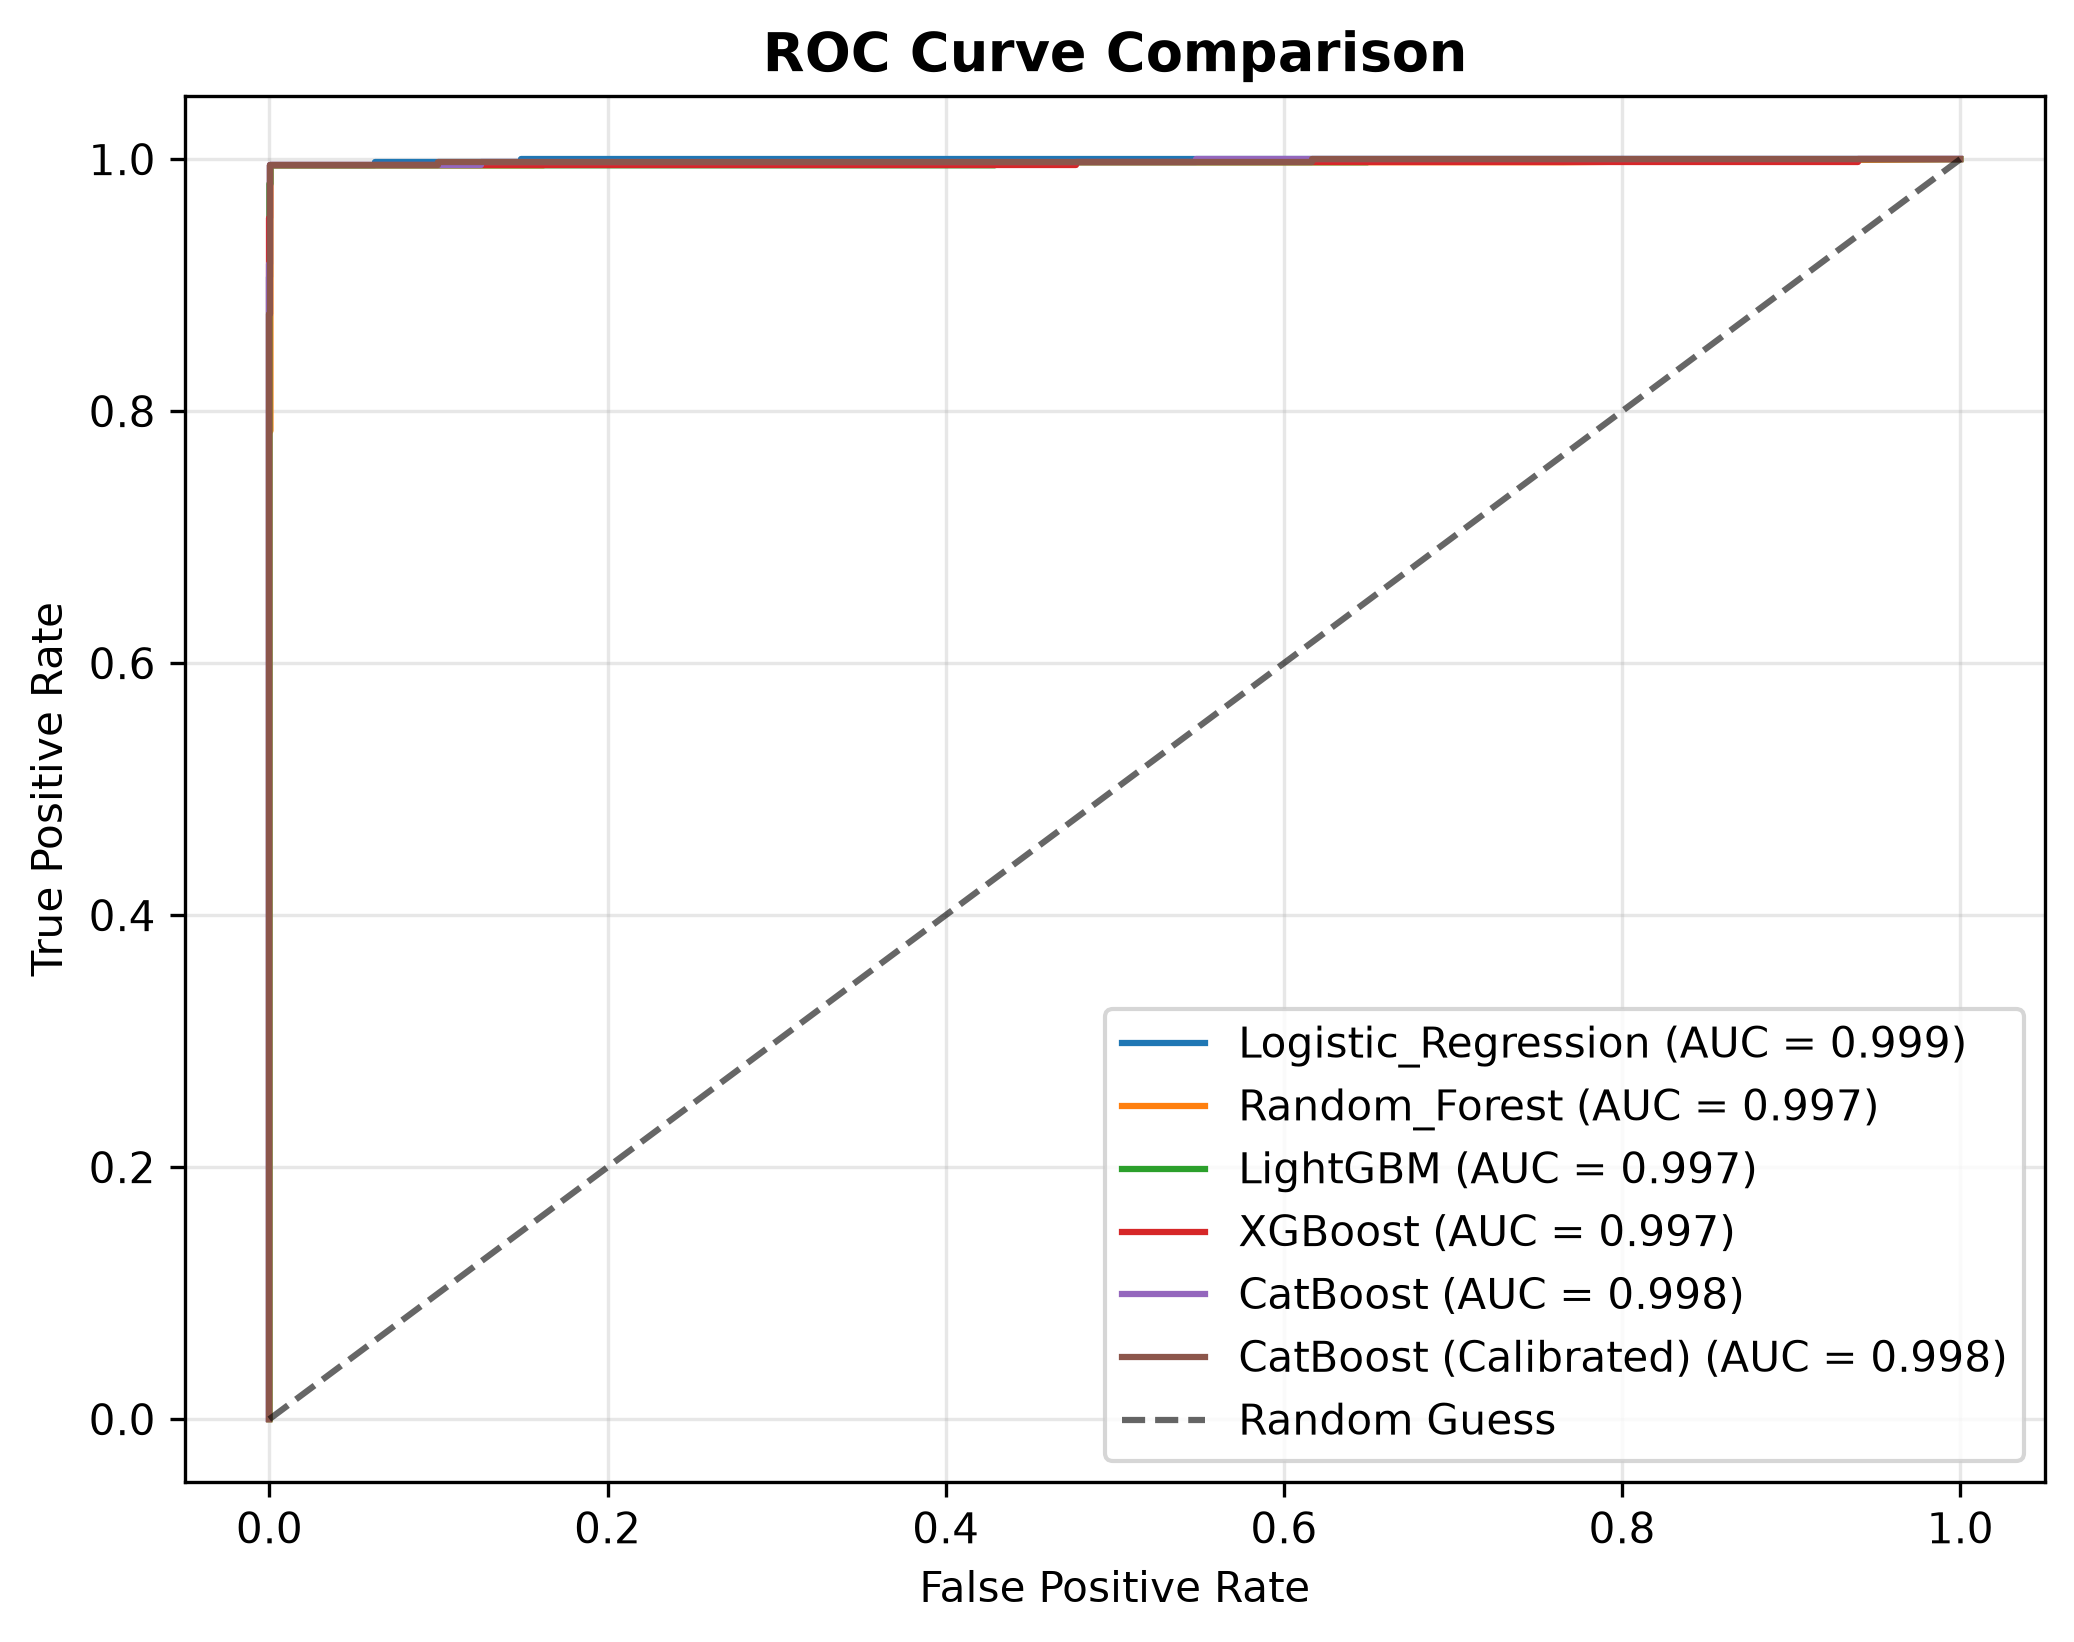

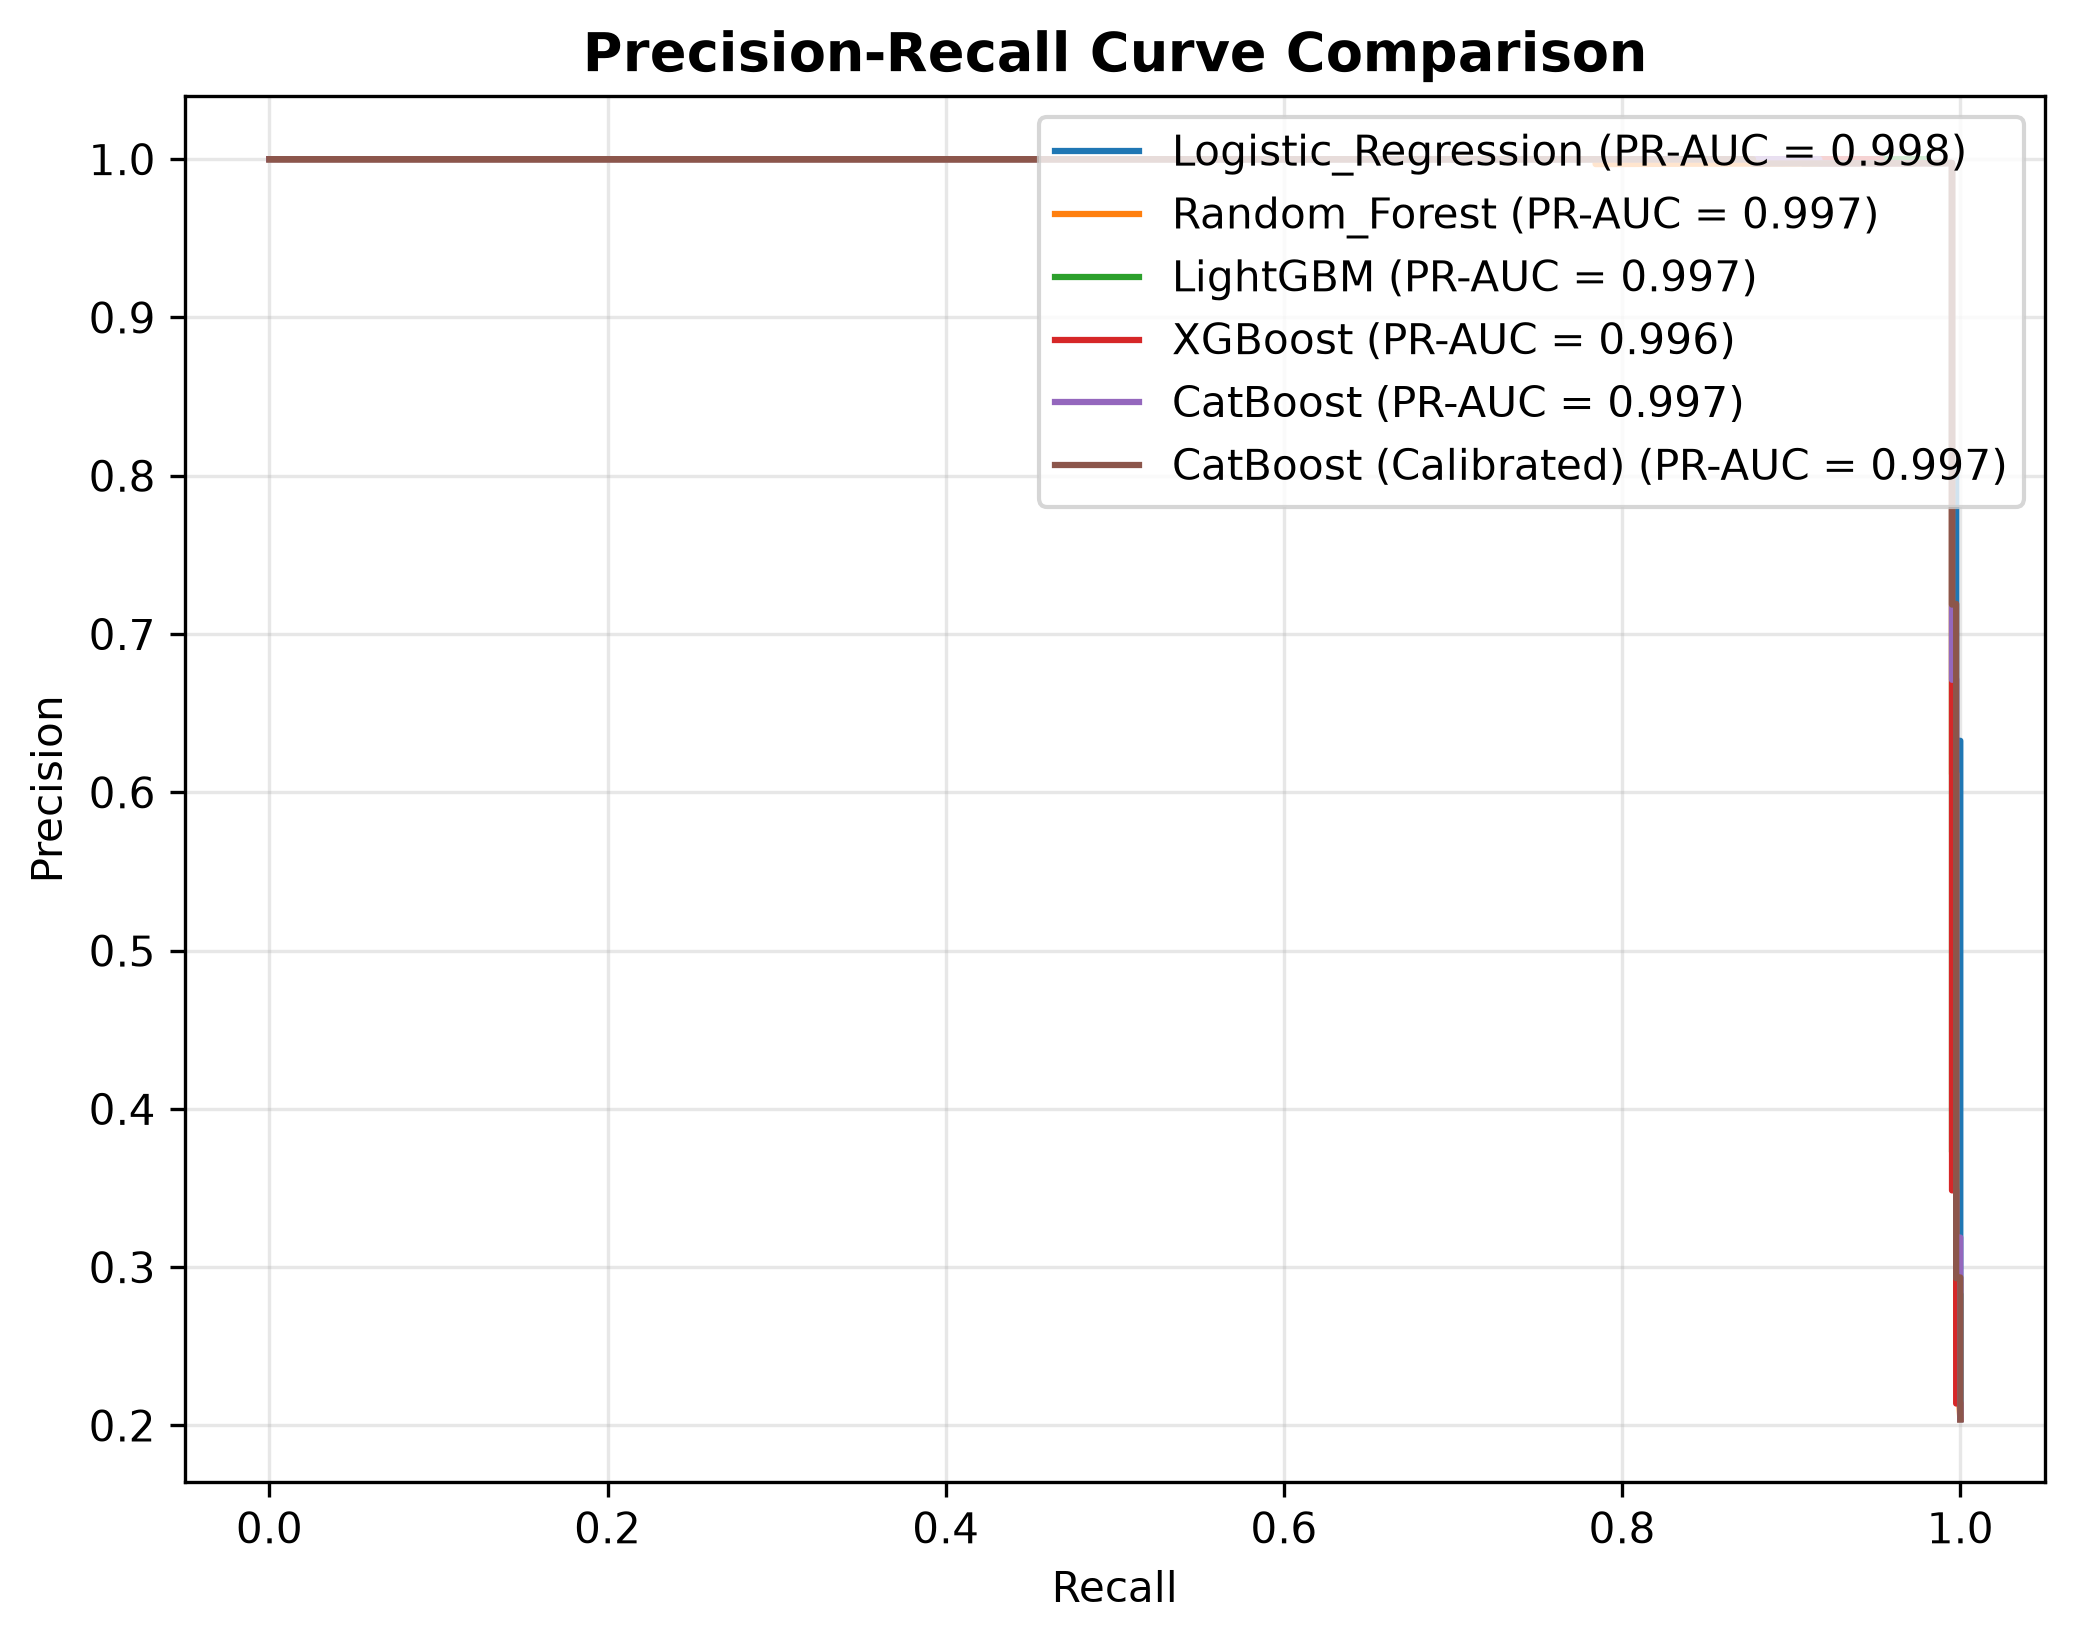

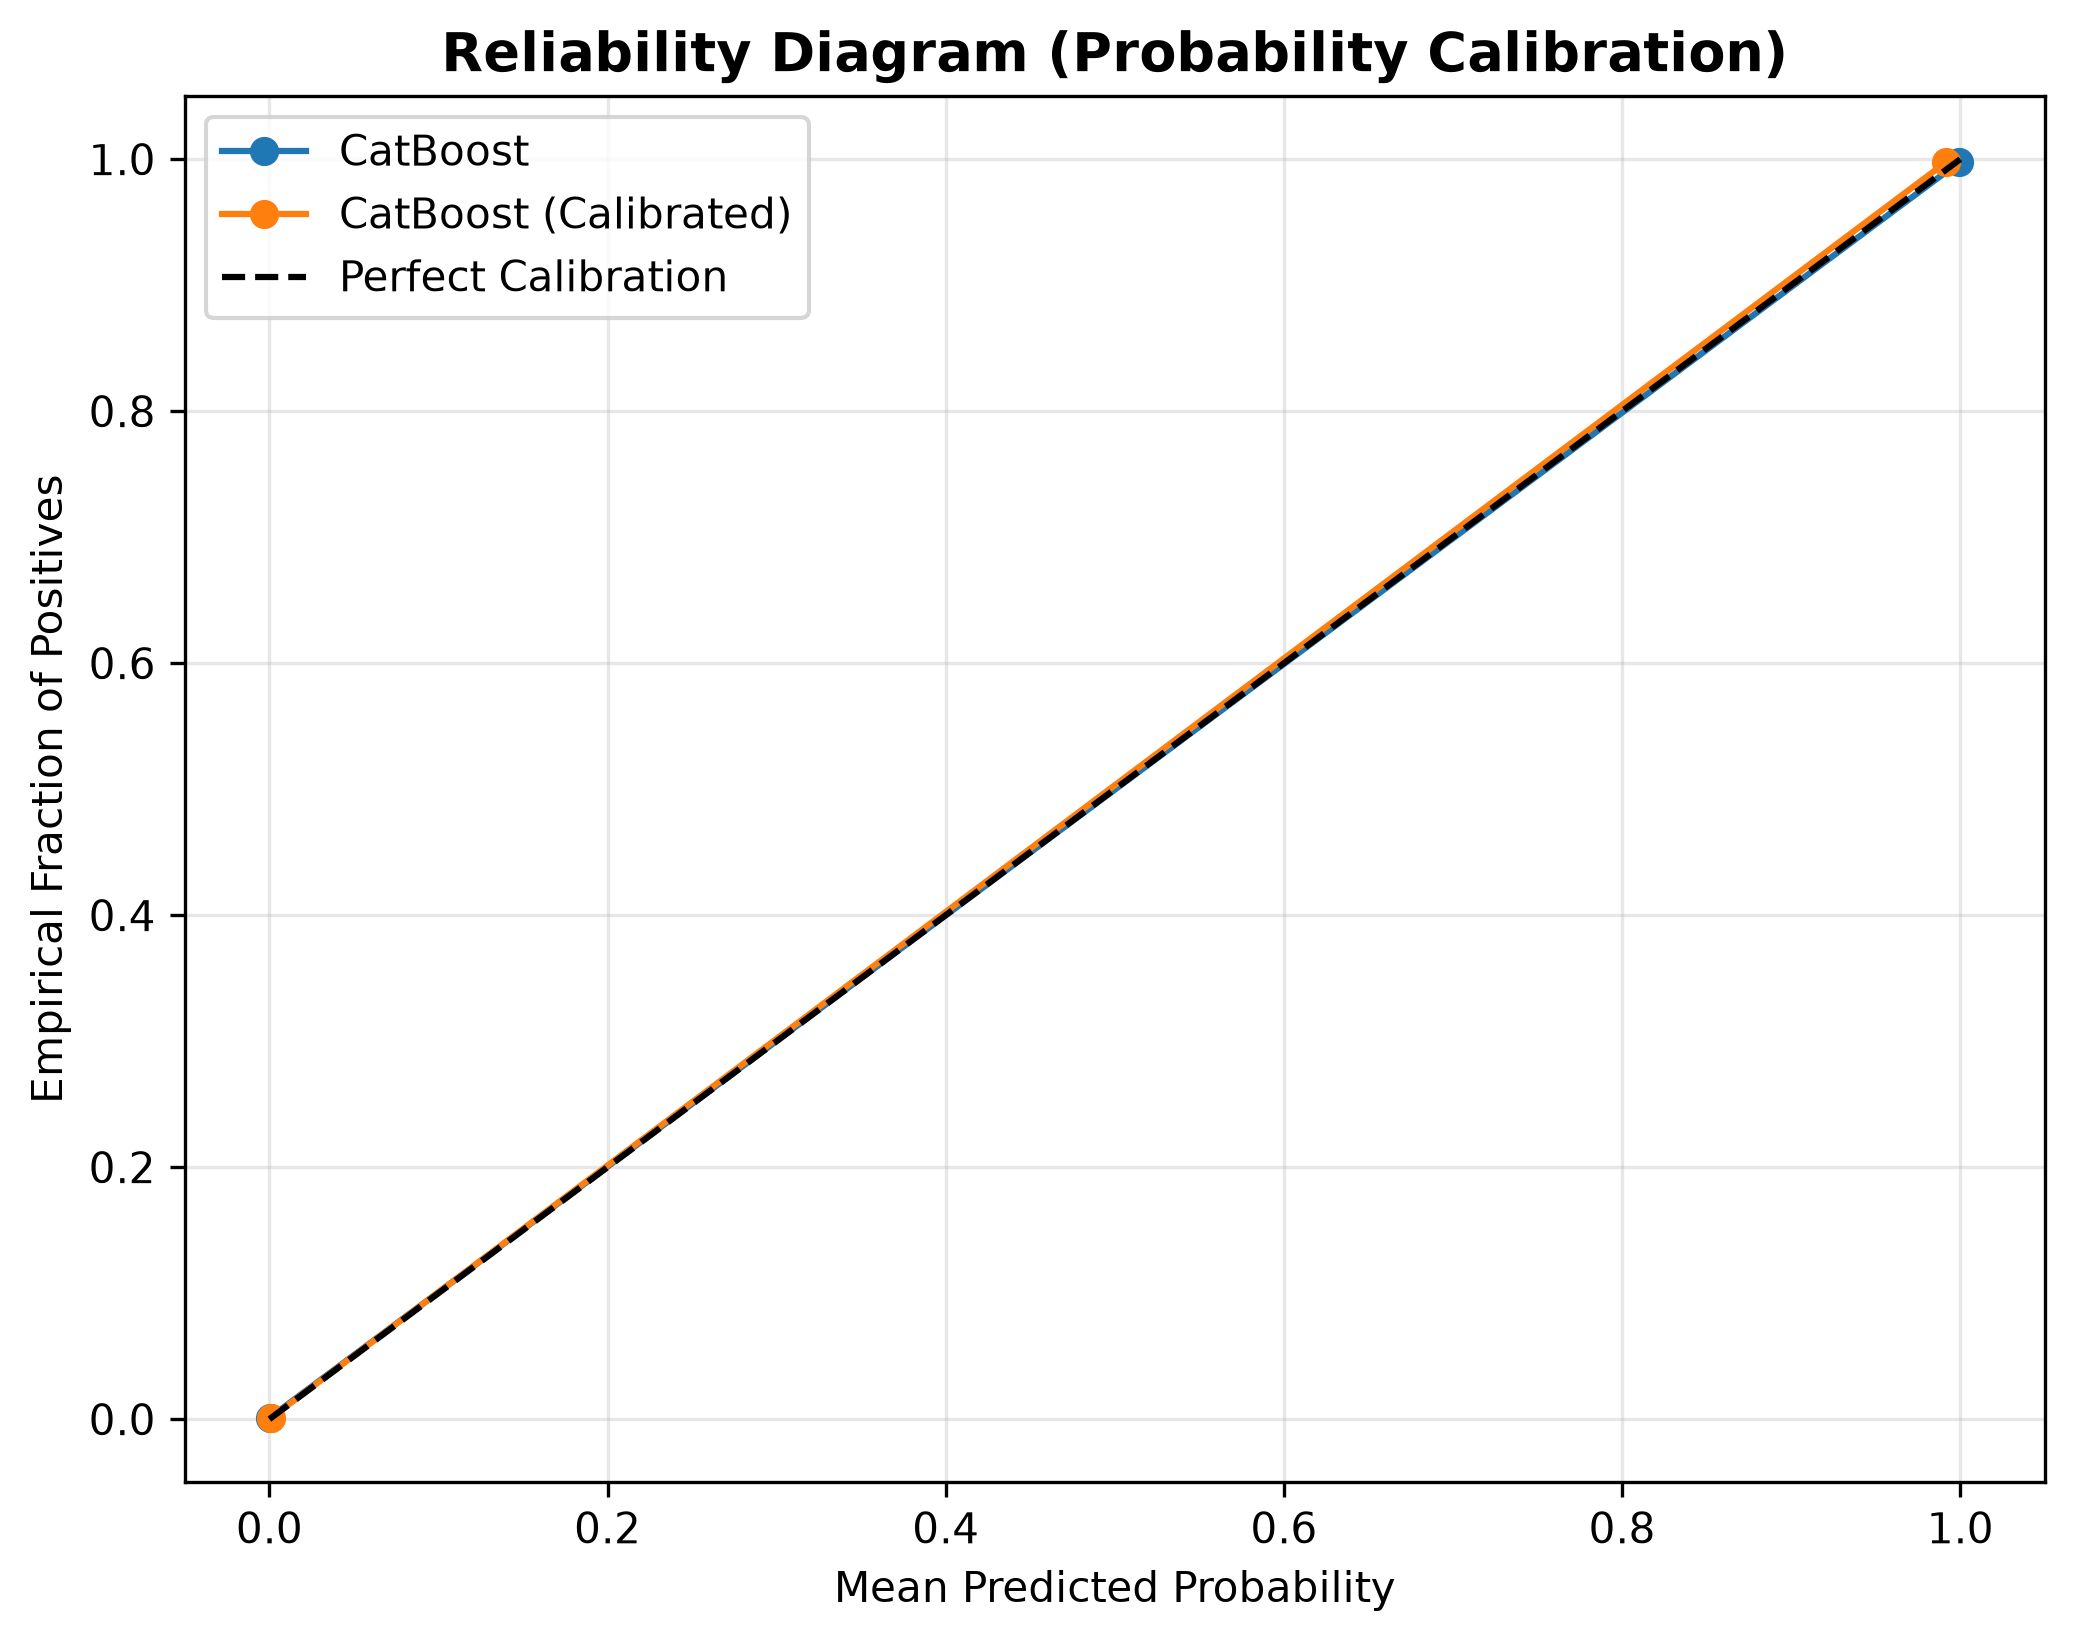

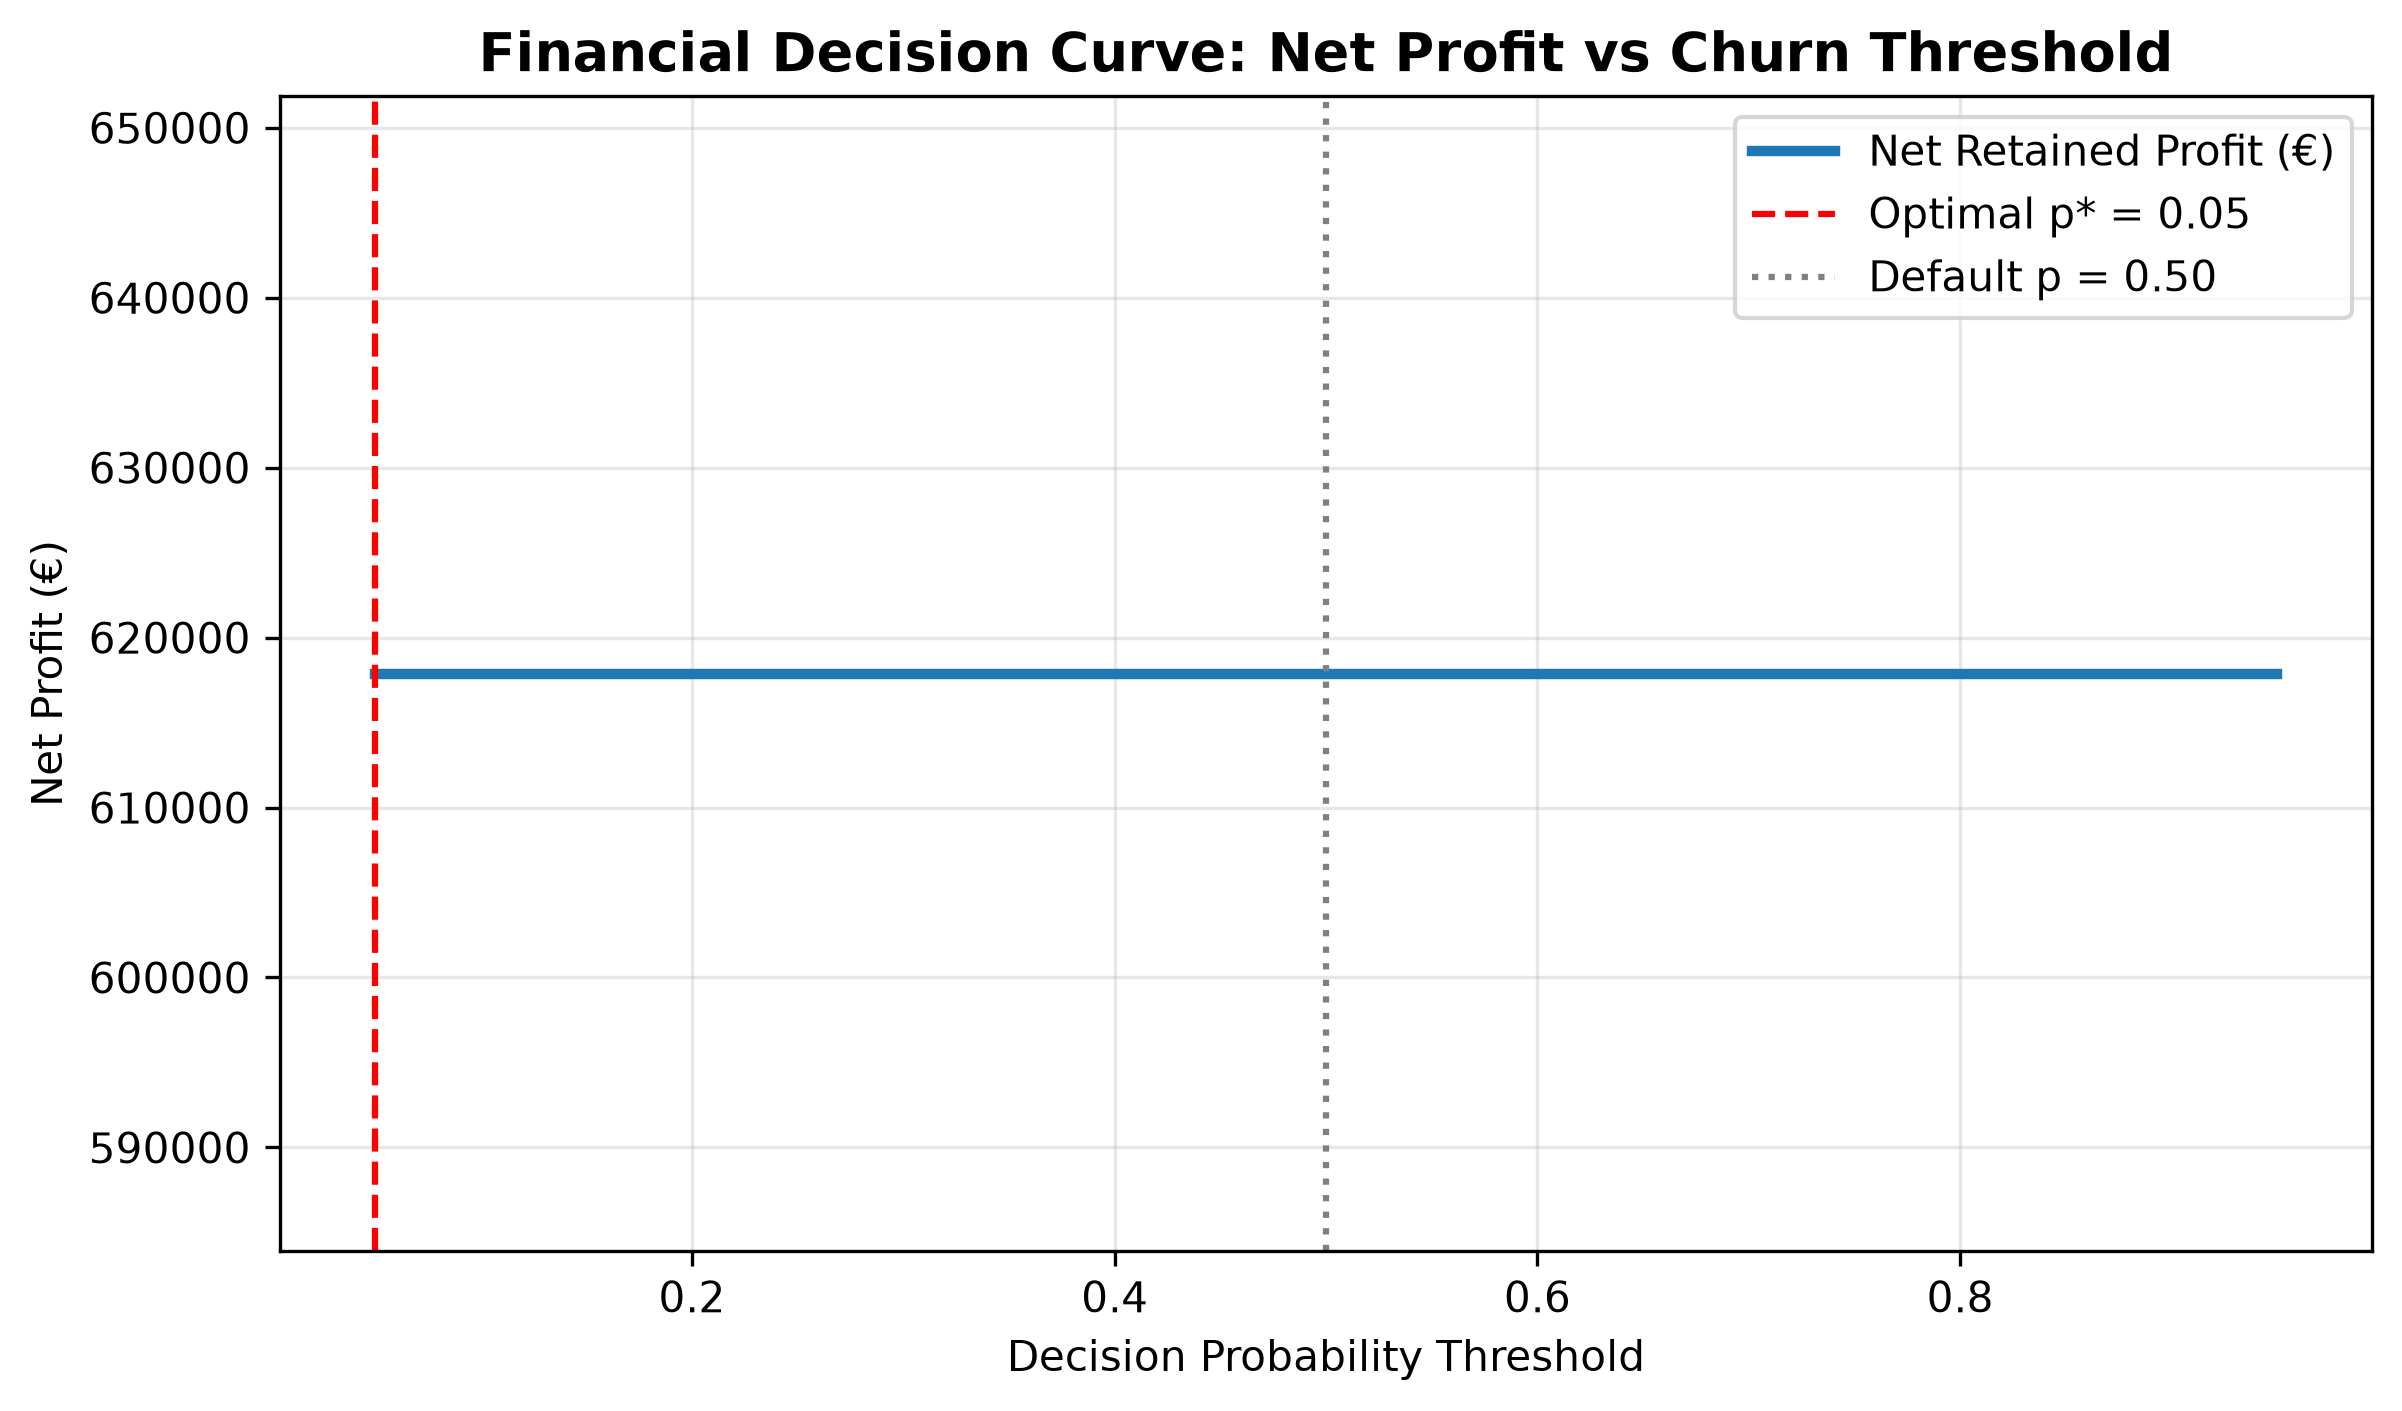

In [5]:
from IPython.display import Image, display

display(Image(filename=str(FIGURES_DIR / "roc_curve_comparison.png")))
display(Image(filename=str(FIGURES_DIR / "pr_curve_comparison.png")))
display(Image(filename=str(FIGURES_DIR / "calibration_reliability_curves.png")))
display(Image(filename=str(FIGURES_DIR / "cost_curve_profit_optimization.png")))